# Soil Analysis & Crop Recommendation with PyTorch

This notebook trains a neural network that recommends one of **22 crops** from seven soil and climate measurements:

| Feature | Meaning |
|---|---|
| `N`, `P`, `K` | Nitrogen, phosphorus, potassium content of the soil |
| `temperature` | °C |
| `humidity` | relative humidity, % |
| `ph` | soil pH |
| `rainfall` | mm |

**Pipeline:** load data → explore → stratified split & scaling → MLP in PyTorch → evaluate → save → recommend crops with a soil report.

The reusable code lives in `crop_model.py`; this notebook shows each step.

In [1]:
import inspect
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import torch
import crop_model as cm

sns.set_theme(style="whitegrid")
cm.set_seed()
device = cm.get_device()
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.14.1+cpu | device: cpu


## 1. Load and inspect the data

In [2]:
df = cm.load_dataframe("data/Crop_recommendation.csv")
print(df.shape, "| missing values:", int(df.isna().sum().sum()), "| duplicate rows:", int(df.duplicated().sum()))
df.head()

(2200, 8) | missing values: 0 | duplicate rows: 0


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.55,36.92,0.00,21.00,37.00,84.25,140.00
P,2200.0,53.36,32.99,5.00,28.00,51.00,68.00,145.00
K,2200.0,48.15,50.65,5.00,20.00,32.00,49.00,205.00
temperature,2200.0,25.62,5.06,8.83,22.77,25.60,28.56,43.68
humidity,2200.0,71.48,22.26,14.26,60.26,80.47,89.95,99.98
ph,2200.0,6.47,0.77,3.50,5.97,6.43,6.92,9.94
rainfall,2200.0,103.46,54.96,20.21,64.55,94.87,124.27,298.56


In [4]:
print(df["label"].nunique(), "crops; samples per crop:")
df["label"].value_counts().describe()[["min", "max"]]

22 crops; samples per crop:


min    100.0
max    100.0
Name: count, dtype: float64

## 2. Exploratory analysis
Each crop has exactly 100 samples, so the classes are balanced and plain accuracy is a fair metric.

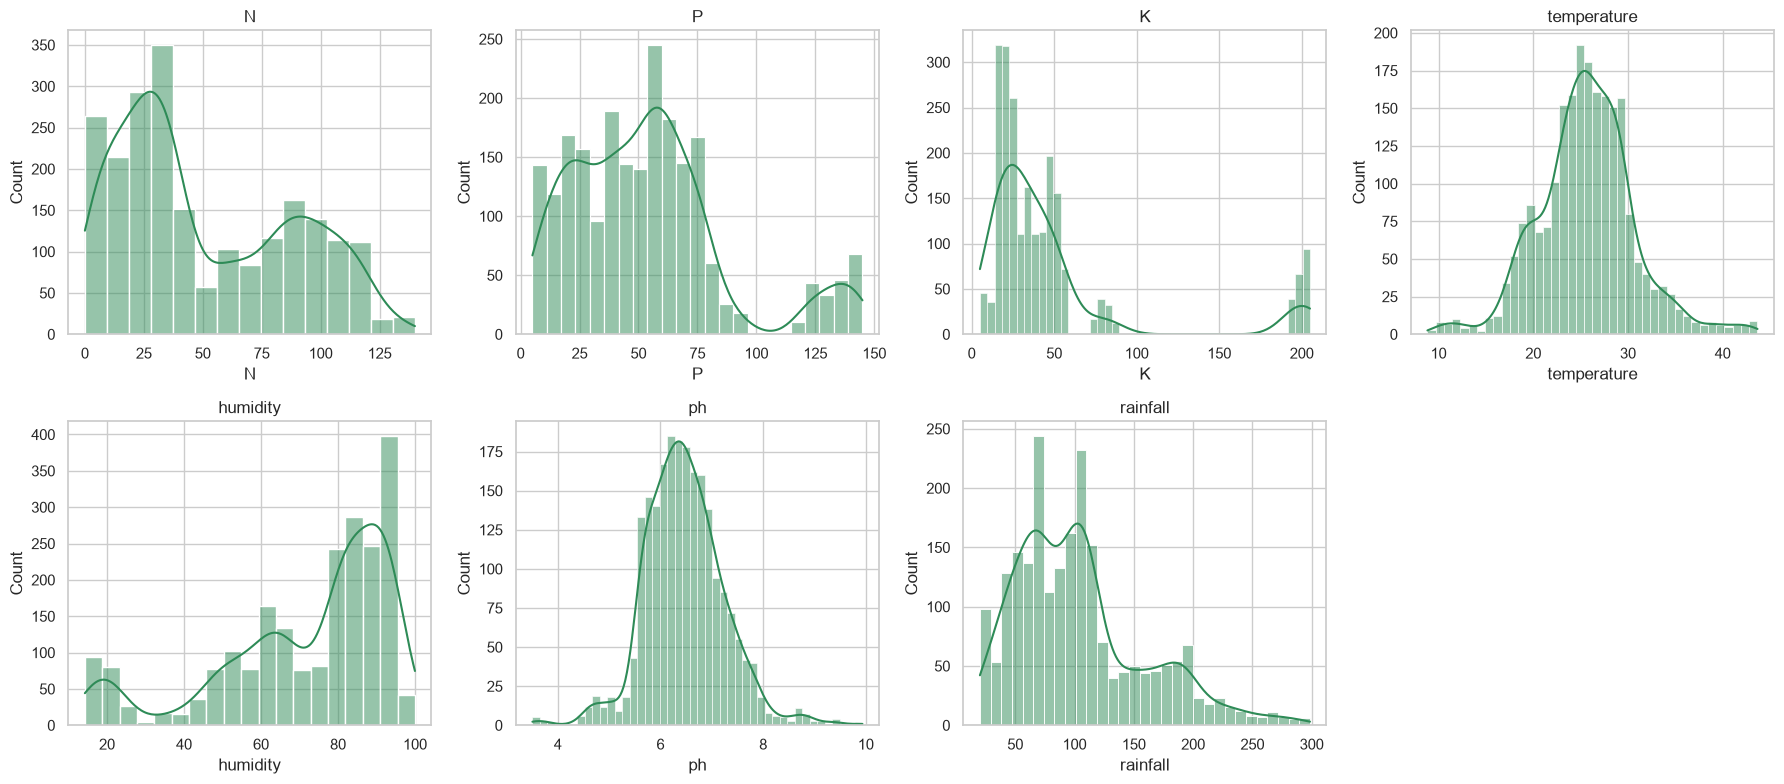

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, f in zip(axes.ravel(), cm.FEATURES):
    sns.histplot(df[f], kde=True, ax=ax, color="seagreen")
    ax.set_title(f)
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

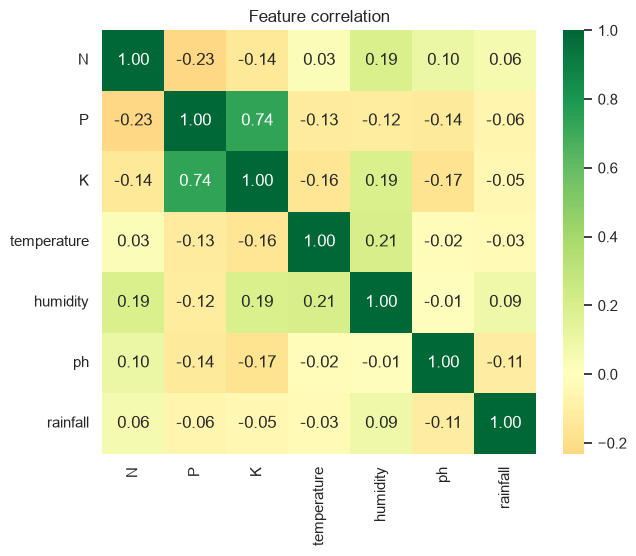

In [6]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(df[cm.FEATURES].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Feature correlation"); plt.show()

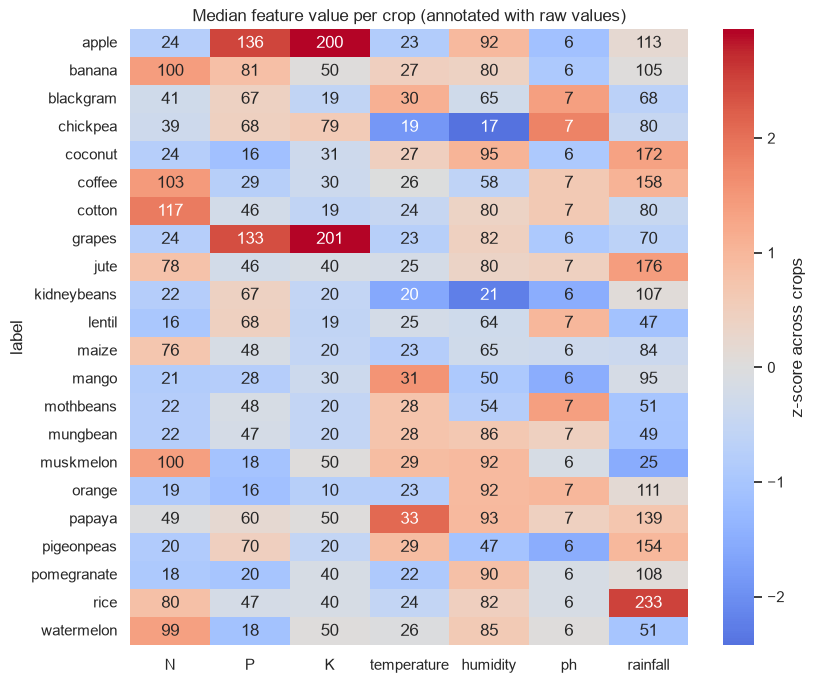

In [7]:
# Median soil nutrients per crop: crops separate clearly, which is why the model works well
med = df.groupby("label")[cm.FEATURES].median().round(1)
plt.figure(figsize=(9, 8))
sns.heatmap((med - med.mean()) / med.std(), cmap="coolwarm", center=0, annot=med, fmt=".0f", cbar_kws={"label": "z-score across crops"})
plt.title("Median feature value per crop (annotated with raw values)"); plt.show()

## 3. Split and scale
Stratified **70 / 15 / 15** train / validation / test split. The scaler (mean/std) is fit on the **training split only**, so no information leaks from validation or test data.

In [8]:
data = cm.prepare_data(df)
classes = data["classes"]
print({k: data[k].shape for k in ["X_train", "X_val", "X_test"]})
print(len(classes), "classes:", classes)

train_loader = cm.make_loader(data["X_train"], data["y_train"], batch_size=64, shuffle=True)
val_loader   = cm.make_loader(data["X_val"],   data["y_val"],   batch_size=64)

{'X_train': (1540, 7), 'X_val': (330, 7), 'X_test': (330, 7)}
22 classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


## 4. The model
A small multilayer perceptron: two hidden layers (128 → 64) with batch norm, ReLU and dropout.

In [9]:
print(inspect.getsource(cm.CropNet))
model = cm.CropNet(n_classes=len(classes))
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

class CropNet(nn.Module):
    """Small MLP: 7 soil/climate features -> probability over crops."""

    def __init__(self, n_features: int = len(FEATURES), n_classes: int = 22,
                 hidden=(128, 64), dropout: float = 0.2):
        super().__init__()
        layers, prev = [], n_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)  # raw logits

CropNet(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats

## 5. Train
AdamW with label smoothing, learning-rate reduction on plateau, and early stopping on validation loss (the best weights are restored).

In [10]:
model, hist = cm.train_model(model, train_loader, val_loader, device)

epoch   1 | train loss 2.3433 acc 0.4448 | val loss 1.8159 acc 0.7394
epoch  10 | train loss 0.6099 acc 0.9390 | val loss 0.4743 acc 0.9848
epoch  20 | train loss 0.5570 acc 0.9474 | val loss 0.4434 acc 0.9818
epoch  30 | train loss 0.5578 acc 0.9558 | val loss 0.4348 acc 0.9879
epoch  40 | train loss 0.5356 acc 0.9597 | val loss 0.4428 acc 0.9818
epoch  50 | train loss 0.5353 acc 0.9610 | val loss 0.4267 acc 0.9848
epoch  60 | train loss 0.5260 acc 0.9636 | val loss 0.4282 acc 0.9818
epoch  70 | train loss 0.5123 acc 0.9714 | val loss 0.4172 acc 0.9848
epoch  80 | train loss 0.5095 acc 0.9656 | val loss 0.4154 acc 0.9879
epoch  90 | train loss 0.4984 acc 0.9675 | val loss 0.4122 acc 0.9879
epoch 100 | train loss 0.5021 acc 0.9649 | val loss 0.4061 acc 0.9848
epoch 110 | train loss 0.4986 acc 0.9688 | val loss 0.4073 acc 0.9909
epoch 120 | train loss 0.4831 acc 0.9721 | val loss 0.4140 acc 0.9879
epoch 130 | train loss 0.4864 acc 0.9701 | val loss 0.4081 acc 0.9909
Early stopping at ep

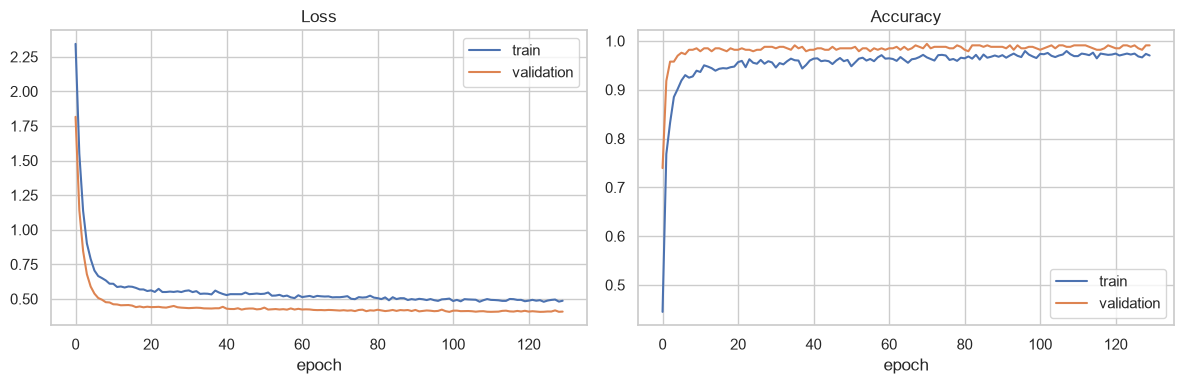

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train_loss"], label="train"); ax[0].plot(hist["val_loss"], label="validation")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["train_acc"], label="train"); ax[1].plot(hist["val_acc"], label="validation")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Evaluate on the held-out test set

In [12]:
y_pred, probs = cm.predict_all(model, data["X_test"], device)
y_true = data["y_test"]
print(f"Test accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, target_names=classes, digits=3))

Test accuracy: 0.9909

              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        15
      banana      1.000     1.000     1.000        15
   blackgram      0.938     1.000     0.968        15
    chickpea      1.000     1.000     1.000        15
     coconut      1.000     1.000     1.000        15
      coffee      1.000     1.000     1.000        15
      cotton      0.938     1.000     0.968        15
      grapes      1.000     1.000     1.000        15
        jute      0.938     1.000     0.968        15
 kidneybeans      1.000     1.000     1.000        15
      lentil      1.000     0.933     0.966        15
       maize      1.000     0.933     0.966        15
       mango      1.000     1.000     1.000        15
   mothbeans      1.000     1.000     1.000        15
    mungbean      1.000     1.000     1.000        15
   muskmelon      1.000     1.000     1.000        15
      orange      1.000     1.000     1.000        15
    

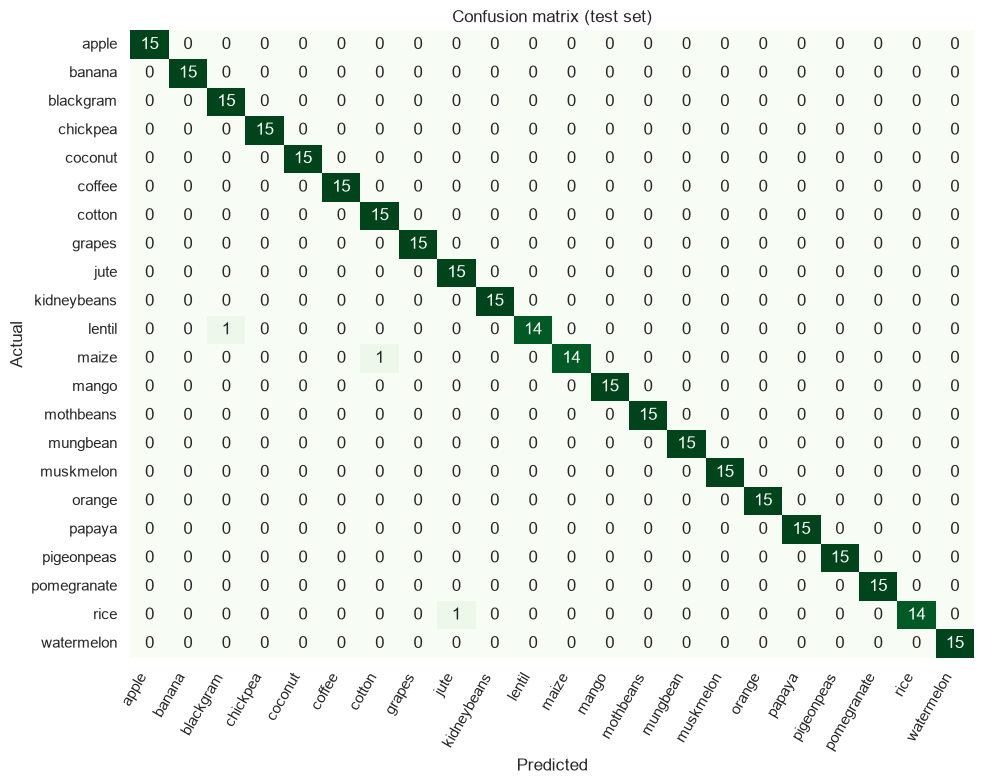

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion matrix (test set)")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()

In [14]:
# Sanity check against a classical baseline on the same split
rf = RandomForestClassifier(n_estimators=300, random_state=cm.SEED).fit(data["X_train"], data["y_train"])
print(f"Random forest baseline test accuracy: {rf.score(data['X_test'], y_true):.4f}")
print(f"PyTorch MLP test accuracy:            {accuracy_score(y_true, y_pred):.4f}")

Random forest baseline test accuracy: 0.9939
PyTorch MLP test accuracy:            0.9909


## 7. Which features matter?
Permutation importance: shuffle one feature in the test set and see how much accuracy drops.

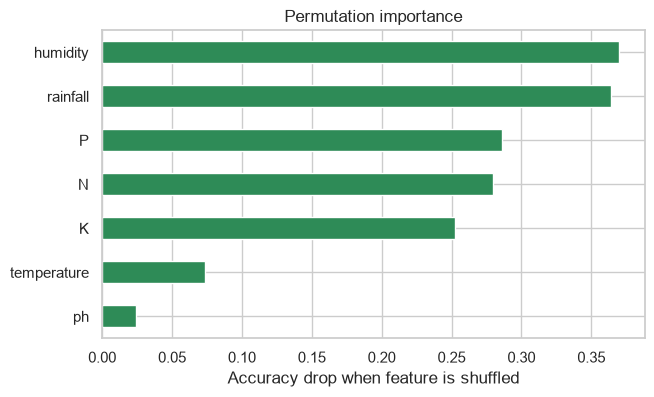

In [15]:
rng = np.random.default_rng(cm.SEED)
base = accuracy_score(y_true, y_pred)
drops = {}
for i, f in enumerate(cm.FEATURES):
    scores = []
    for _ in range(10):
        Xp = data["X_test"].copy()
        Xp[:, i] = rng.permutation(Xp[:, i])
        scores.append(accuracy_score(y_true, cm.predict_all(model, Xp, device)[0]))
    drops[f] = base - np.mean(scores)
pd.Series(drops).sort_values().plot.barh(color="seagreen", figsize=(7, 4))
plt.xlabel("Accuracy drop when feature is shuffled"); plt.title("Permutation importance"); plt.show()

## 8. Save the model

In [16]:
cm.save_bundle("artifacts/crop_model.pt", model, data)
loaded, bundle = cm.load_bundle("artifacts/crop_model.pt")
print("Saved and reloaded. Classes:", len(bundle["classes"]))

Saved and reloaded. Classes: 22


## 9. Recommend a crop and analyse the soil
Edit the values below. The report compares your values to the typical range (10th–90th percentile) of the top recommended crop.

In [17]:
sample = {"N": 90, "P": 42, "K": 43, "temperature": 21.0, "humidity": 82.0, "ph": 6.5, "rainfall": 203.0}

results = cm.recommend(loaded, bundle, sample, top_k=3)
print("Top recommendations:")
for crop, p in results:
    print(f"  {crop:<12}{p*100:5.1f}%")
print("\nSoil analysis for", results[0][0] + ":")
for line in cm.soil_report(sample, df, results[0][0]):
    print(" -", line)

Top recommendations:
  rice         77.1%
  jute         20.6%
  papaya        0.3%

Soil analysis for rice:
 - Soil pH 6.5: neutral.
 - N: 90.0 is within the typical range for rice (62.9-95.0).
 - P: 42.0 is within the typical range for rice (36.0-58.0).
 - K: 43.0 is within the typical range for rice (36.0-44.0).
 - temperature: 21.0 is within the typical range for rice (20.9-26.5).
 - humidity: 82.0 is within the typical range for rice (80.3-84.1).
 - ph: 6.5 is within the typical range for rice (5.4-7.5).
 - rainfall: 203.0 is within the typical range for rice (191.6-284.0).


In [18]:
# A second example: dry, warm, low-nitrogen conditions
sample2 = {"N": 20, "P": 60, "K": 20, "temperature": 28.0, "humidity": 50.0, "ph": 7.2, "rainfall": 60.0}
for crop, p in cm.recommend(loaded, bundle, sample2, top_k=3):
    print(f"{crop:<12}{p*100:5.1f}%")

mothbeans    82.4%
blackgram     7.8%
lentil        5.8%


## Notes and limitations
- The dataset is small (2,200 rows) and quite clean, so very high accuracy is expected; real field data is noisier and results on real farms will be lower.
- The model recommends crops that match the *training data's* typical conditions. It does not account for market prices, crop rotation, soil texture, or local agronomic advice.
- Use it as a decision-support tool, not a replacement for a soil test or an agronomist.